In [1]:
import sys
import yaml
import numpy as np
sys.path.append("..")
from src.data_generation.SSVI import ssvi, sample_params

cfg = yaml.safe_load(open("../config.yaml"))["ssvi_prior"]

In [2]:
ttms = np.linspace(1/12, 1.0, 50)
ks   = np.linspace(-0.5, 0.5, 50)
np.random.seed(2)
rho, nu, gamma, v_bar, v0, kappa = sample_params(cfg, n=1000)

In [3]:
surfaces = ssvi(ttms, ks, rho, nu, gamma, v_bar, v0, kappa) 
surfaces[0]

array([[0.56255981, 0.55232561, 0.54190025, ..., 0.24917268, 0.25383555,
        0.25842164],
       [0.53773958, 0.52809438, 0.5182721 , ..., 0.23867034, 0.24303784,
        0.2473371 ],
       [0.51832471, 0.50914785, 0.49980516, ..., 0.23052285, 0.23465158,
        0.2387193 ],
       ...,
       [0.35501919, 0.35039778, 0.34572177, ..., 0.17324451, 0.17435335,
        0.17554221],
       [0.35402408, 0.34943685, 0.34479581, ..., 0.17311463, 0.17418877,
        0.17534492],
       [0.35305421, 0.34850041, 0.34389356, ..., 0.17299524, 0.17403514,
        0.17515902]])

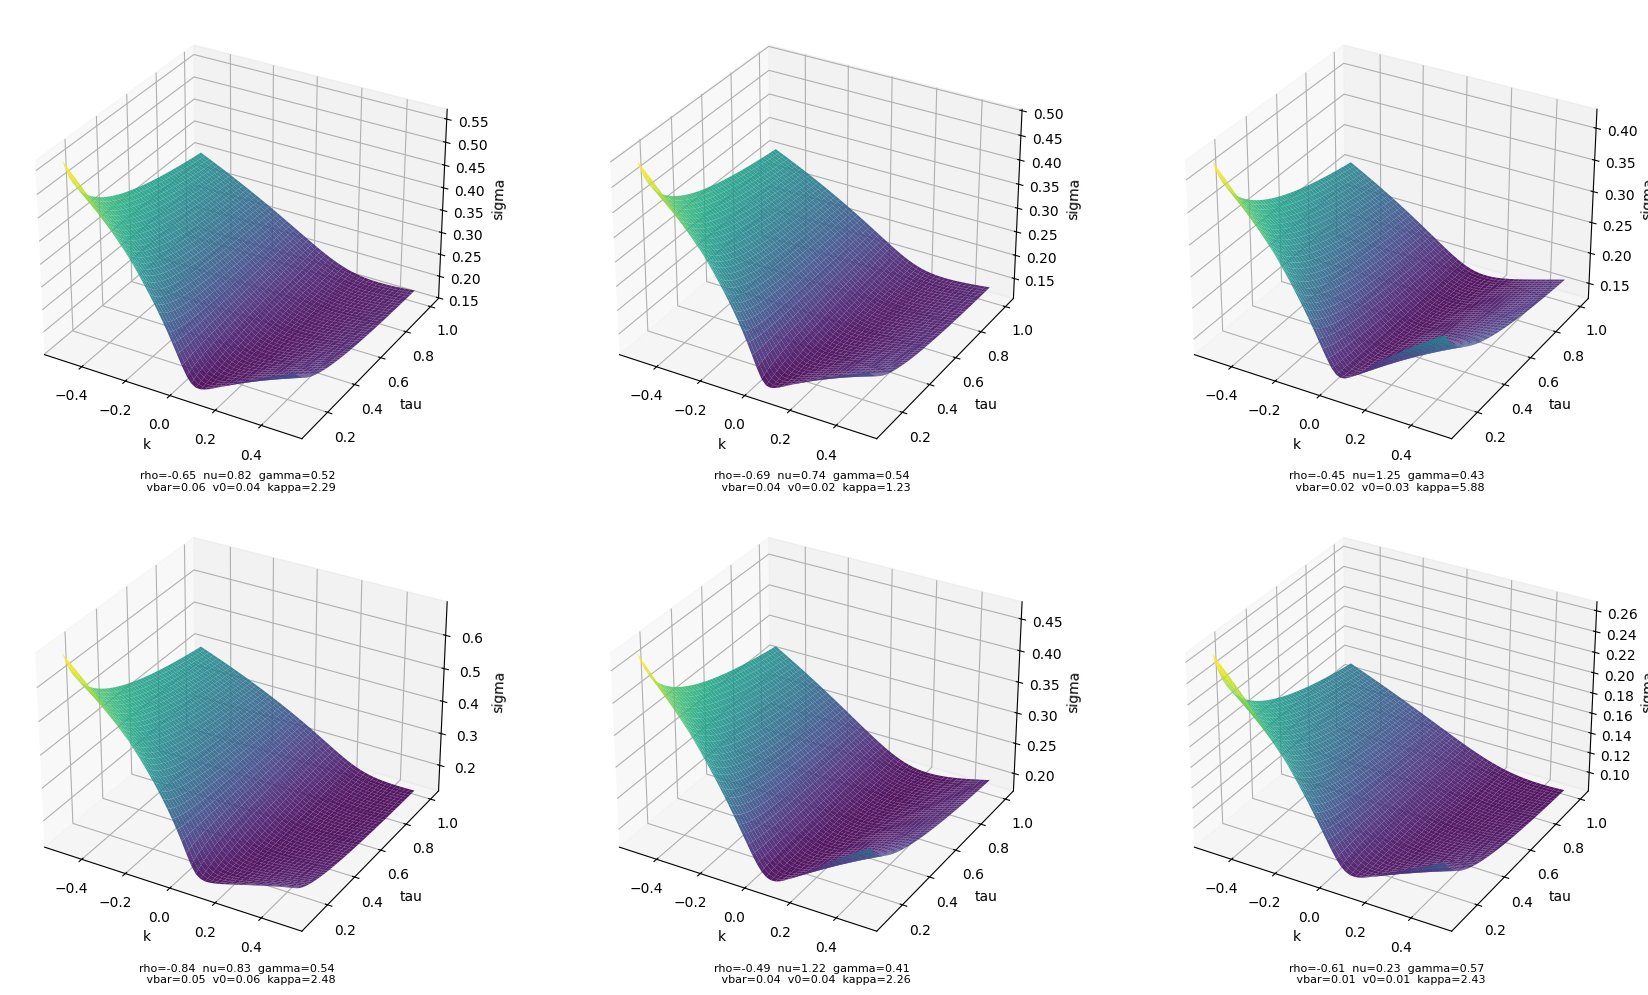

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={"projection": "3d"})
K, T = np.meshgrid(ks, ttms)

for i, ax in enumerate(axes.flat):
    iv = surfaces[i]
    ax.plot_surface(K, T, iv, cmap="viridis", edgecolor="none", alpha=0.9)
    ax.set_xlabel("k")
    ax.set_ylabel("tau")
    ax.set_zlabel("sigma")
    label = (
        f"rho={rho[i]:.2f}  nu={nu[i]:.2f}  gamma={gamma[i]:.2f} \n "
        f"vbar={v_bar[i]:.2f}  v0={v0[i]:.2f}  kappa={kappa[i]:.2f}"
    )
    ax.text2D(0.5, -0.05, label, transform=ax.transAxes, ha="center", fontsize=8)

plt.tight_layout()
plt.show()